In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import recall_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier



In [ ]:
file_path = '/content/Consulting_survey_DataSet (3).csv'
df = pd.read_csv(file_path)


In [ ]:
df

,Timestamp,Do you CURRENTLY work at a consulting firm?,Which firm do you CURRENTLY work for?,Are you CURRENTLY in a Commercial or Federal practice?,What is your CURRENT title (or equivalent)?,What COUNTRY are you CURRENTLY based out of?,"What is your CURRENT annual base compensation in USD (not including bonuses, perks, or other incentives)? Please consult Google for conversion tools for local currency into USD. Enter number values only.",What is the total amount in USD of BONUSES you estimate you will receive in 2021? Enter number only.,Expected total compensation (calculated),How many hours per week on AVERAGE do you work (including non-billable time)?,Have you gotten an OFFER from another company this year?,Was the offer from another CONSULTING FIRM?,Which firm was the HIGHEST (base compensation) OFFER from?,Was the OFFER for a Commercial or Federal practice?,What was the OFFERED title (or equivalent)?,What COUNTRY was the OFFER based out of?,"What was the HIGHEST OFFERED annual base compensation in USD (not including bonuses, perks, or other incentives)? Please consult Google for conversion tools for local currency into USD. Enter a number only.",What was the total annual BONUS OFFERED?,Did you accept the offer?
0,9/29/2021 10:35:35,Yes,Other or Boutique,Commercial/non-federal Practice,Consultant/Associate,United States of America,147000.0,17000.0,164000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9/29/2021 10:35:44,Yes,McKinsey,Commercial/non-federal Practice,Senior Manager,Malaysia,142000.0,50000.0,192000.0,60-69,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9/29/2021 10:36:00,Yes,Deloitte,Commercial/non-federal Practice,Senior Consultant/Senior Associate,United States of America,150000.0,30000.0,180000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9/29/2021 10:36:16,Yes,Deloitte,Federal/government Practice,Senior Consultant/Senior Associate,United States of America,95000.0,10000.0,105000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9/29/2021 10:36:19,Yes,Kearney,Commercial/non-federal Practice,Consultant/Associate,United States of America,165000.0,32000.0,197000.0,70-79,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,10/19/2021 8:21:36,Yes,PwC,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United States of America,111000.0,8500.0,119500.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4196,10/19/2021 8:29:55,Yes,EY Parthenon,Commercial/non-federal Practice,Senior Manager,India,54000.0,10000.0,64000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4197,10/19/2021 10:13:15,Yes,Accenture,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United Kingdom,72000.0,0.0,72000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4198,10/19/2021 10:30:46,No,NaN,NaN,NaN,United States of America,85800.0,0.0,85800.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df.columns.tolist())


['Timestamp', 'Do you CURRENTLY work at a consulting firm?', 'Which firm do you CURRENTLY work for?', 'Are you CURRENTLY in a Commercial or Federal practice? ', 'What is your CURRENT title (or equivalent)? ', 'What COUNTRY are you CURRENTLY based out of?', 'What is your CURRENT annual base compensation in USD (not including bonuses, perks, or other incentives)? Please consult Google for conversion tools for local currency into USD. Enter number values only.', 'What is the total amount in USD of BONUSES you estimate you will receive in 2021? Enter number only.', 'Expected total compensation (calculated)', 'How many hours per week on AVERAGE do you work (including non-billable time)?', 'Have you gotten an OFFER from another company this year?', 'Was the offer from another CONSULTING FIRM?', 'Which firm was the HIGHEST (base compensation) OFFER from?', 'Was the OFFER for a Commercial or Federal practice? ', 'What was the OFFERED title (or equivalent)? ', 'What COUNTRY was the OFFER based 

In [ ]:
# Renaming the columns to shorter and easier-to-use names
df.columns = [
    'timestamp',
    'current_consulting_firm',
    'current_firm',
    'current_practice',
    'current_title',
    'current_country',
    'current_compensation_usd',
    'estimated_bonus_usd_2021',
    'expected_total_compensation',
    'weekly_hours',
    'offer_received',
    'offer_from_consulting_firm',
    'highest_offer_firm',
    'offer_practice',
    'offered_title',
    'offer_country',
    'highest_offer_compensation_usd',
    'highest_offer_bonus_usd',
    'accepted_offer'
]


print(df.columns.tolist())


['timestamp', 'current_consulting_firm', 'current_firm', 'current_practice', 'current_title', 'current_country', 'current_compensation_usd', 'estimated_bonus_usd_2021', 'expected_total_compensation', 'weekly_hours', 'offer_received', 'offer_from_consulting_firm', 'highest_offer_firm', 'offer_practice', 'offered_title', 'offer_country', 'highest_offer_compensation_usd', 'highest_offer_bonus_usd', 'accepted_offer']


In [ ]:
df

,timestamp,current_consulting_firm,current_firm,current_practice,current_title,current_country,current_compensation_usd,estimated_bonus_usd_2021,expected_total_compensation,weekly_hours,offer_received,offer_from_consulting_firm,highest_offer_firm,offer_practice,offered_title,offer_country,highest_offer_compensation_usd,highest_offer_bonus_usd,accepted_offer
0,9/29/2021 10:35:35,Yes,Other or Boutique,Commercial/non-federal Practice,Consultant/Associate,United States of America,147000.0,17000.0,164000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9/29/2021 10:35:44,Yes,McKinsey,Commercial/non-federal Practice,Senior Manager,Malaysia,142000.0,50000.0,192000.0,60-69,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9/29/2021 10:36:00,Yes,Deloitte,Commercial/non-federal Practice,Senior Consultant/Senior Associate,United States of America,150000.0,30000.0,180000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9/29/2021 10:36:16,Yes,Deloitte,Federal/government Practice,Senior Consultant/Senior Associate,United States of America,95000.0,10000.0,105000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9/29/2021 10:36:19,Yes,Kearney,Commercial/non-federal Practice,Consultant/Associate,United States of America,165000.0,32000.0,197000.0,70-79,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,10/19/2021 8:21:36,Yes,PwC,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United States of America,111000.0,8500.0,119500.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4196,10/19/2021 8:29:55,Yes,EY Parthenon,Commercial/non-federal Practice,Senior Manager,India,54000.0,10000.0,64000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4197,10/19/2021 10:13:15,Yes,Accenture,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United Kingdom,72000.0,0.0,72000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4198,10/19/2021 10:30:46,No,NaN,NaN,NaN,United States of America,85800.0,0.0,85800.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<ipython-input-7-ada6d1e4bb9a>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df[col].fillna(new_df[col].mode()[0], inplace=True)
<ipython-input-7-ada6d1e4bb9a>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

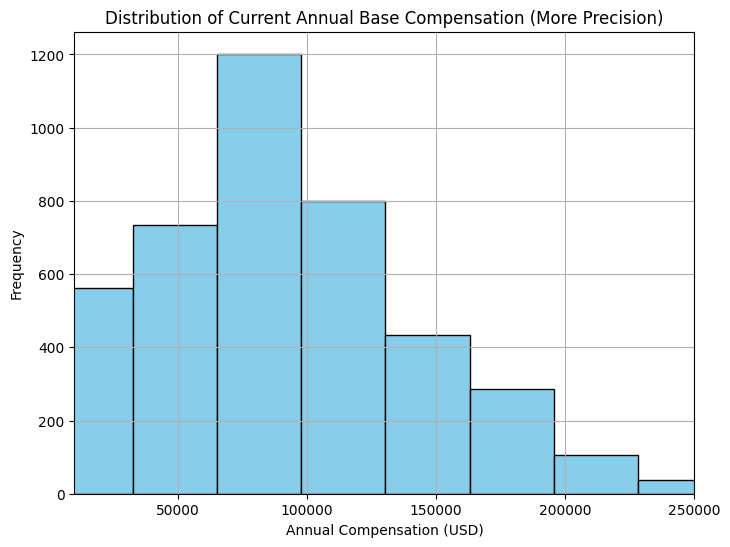

In [ ]:
new_df = df.dropna(how='all')

# Imputing missing values for categorical columns with the mode
categorical_cols = new_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    new_df[col].fillna(new_df[col].mode()[0], inplace=True)

# For numerical columns, filling missing values with the median => It allows to have a clear vision about the dataset instead of deleting missing values
numerical_cols = new_df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    new_df[col].fillna(new_df[col].median(), inplace=True)

# Plotting the distribution of Current Annual Base Compensation with improved scaling
plt.figure(figsize=(8, 6))
plt.hist(new_df['current_compensation_usd'], bins=50, edgecolor='k', color='skyblue')
plt.title('Distribution of Current Annual Base Compensation (More Precision)')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Frequency')
plt.xlim(10000, 250000)  # Setting a reasonable x-axis range
plt.grid(True)
plt.show()

In [ ]:
# Creating a target variable for turnover: whether the consultant accepted an external offer (Yes = 1, No = 0)
new_df['turnover_risk'] = new_df['accepted_offer'].apply(lambda x: 1 if x == 'Yes' else 0)


In [ ]:

print(new_df.columns)

print(new_df['weekly_hours'].isnull().sum())
print(new_df['current_firm'].isnull().sum())


Index(['timestamp', 'current_consulting_firm', 'current_firm',
       'current_practice', 'current_title', 'current_country',
       'current_compensation_usd', 'estimated_bonus_usd_2021',
       'expected_total_compensation', 'weekly_hours', 'offer_received',
       'offer_from_consulting_firm', 'highest_offer_firm', 'offer_practice',
       'offered_title', 'offer_country', 'highest_offer_compensation_usd',
       'highest_offer_bonus_usd', 'accepted_offer', 'turnover_risk'],
      dtype='object')
0
0


In [ ]:

new_df_cleaned = new_df.dropna(subset=['weekly_hours', 'current_firm'])


print(new_df_cleaned.shape)
print(new_df_cleaned.head())


(4200, 20)
            timestamp current_consulting_firm       current_firm  \
0  9/29/2021 10:35:35                     Yes  Other or Boutique   
1  9/29/2021 10:35:44                     Yes           McKinsey   
2  9/29/2021 10:36:00                     Yes           Deloitte   
3  9/29/2021 10:36:16                     Yes           Deloitte   
4  9/29/2021 10:36:19                     Yes            Kearney   

                  current_practice                       current_title  \
0  Commercial/non-federal Practice                Consultant/Associate   
1  Commercial/non-federal Practice                      Senior Manager   
2  Commercial/non-federal Practice  Senior Consultant/Senior Associate   
3      Federal/government Practice  Senior Consultant/Senior Associate   
4  Commercial/non-federal Practice                Consultant/Associate   

            current_country  current_compensation_usd  \
0  United States of America                  147000.0   
1                  Ma

In [ ]:
# First, check the unique values in 'weekly_hours' to identify non-numeric values
print(new_df['weekly_hours'].unique())



['50-59' '60-69' '40-49' '70-79' '<40' '80+'
 'Not applicable/not currently working']


In [ ]:
# Define a function to clean the 'weekly_hours' column
def clean_hours(hours):
    hours_str = str(hours)

    # Handle ranges like '40-50' by taking the average
    if '-' in hours_str:
        min_hour, max_hour = hours_str.split('-')
        return (float(min_hour) + float(max_hour)) / 2

    # Handle '<40' by converting it to a reasonable numeric value (e.g., 40)
    elif '<' in hours_str:
        return float(hours_str.replace('<', ''))

    # Handle '80+' by converting it to 80
    elif '+' in hours_str:
        return float(hours_str.replace('+', ''))

    # Try converting the value to float if it's already numeric
    try:
        return float(hours_str)
    except ValueError:
        return None  # Return None for invalid entries

# Apply the cleaning function to the 'weekly_hours' column
new_df['weekly_hours'] = new_df['weekly_hours'].apply(clean_hours)

# Now, check if 'weekly_hours' is successfully converted to numeric
print(new_df['weekly_hours'].dtype)


float64


In [ ]:
new_df_cleaned = new_df.dropna(subset=['weekly_hours'])

new_df['weekly_hours'].fillna(new_df['weekly_hours'].mean(), inplace=True)


<ipython-input-13-8ff0ecbefdb8>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df['weekly_hours'].fillna(new_df['weekly_hours'].mean(), inplace=True)


In [ ]:
def clean_hours(hours):
    hours_str = str(hours)

    if 'Not applicable' in hours_str or 'not currently working' in hours_str:
        return None  # or return 0 if you prefer to fill missing values with 0

    if '-' in hours_str:
        # Handle ranges like '50-59'
        min_hour, max_hour = hours_str.split('-')
        return (float(min_hour) + float(max_hour)) / 2
    elif '<' in hours_str:
        # Handle '<40' by converting it to 40
        return float(hours_str.replace('<', ''))
    elif '+' in hours_str:
        # Handle '80+' by converting it to 80
        return float(hours_str.replace('+', ''))
    else:
        # Convert any other valid numeric string to float
        return float(hours_str)

# Apply the cleaning function to the weekly_hours column in new_df, filling non-numeric values as NaN
new_df['weekly_hours'] = new_df['weekly_hours'].apply(clean_hours)

# Drop rows where 'weekly_hours' could not be converted (if needed)
new_df.dropna(subset=['weekly_hours'], inplace=True)

# Step 2: Recalculate correlations after cleaning
turnover_risk_correlation = new_df[['turnover_risk',
                                    'current_compensation_usd',
                                    'estimated_bonus_usd_2021',
                                    'expected_total_compensation',
                                    'weekly_hours',
                                    'highest_offer_compensation_usd',
                                    'highest_offer_bonus_usd']].corr()

# Display the updated correlation matrix
print(turnover_risk_correlation)


                                turnover_risk  current_compensation_usd  \
turnover_risk                        1.000000                 -0.034989   
current_compensation_usd            -0.034989                  1.000000   
estimated_bonus_usd_2021             0.002080                  0.042288   
expected_total_compensation         -0.001026                  0.130292   
weekly_hours                         0.022993                  0.088086   
highest_offer_compensation_usd       0.046563                  0.292187   
highest_offer_bonus_usd              0.066672                  0.156105   

                                estimated_bonus_usd_2021  \
turnover_risk                                   0.002080   
current_compensation_usd                        0.042288   
estimated_bonus_usd_2021                        1.000000   
expected_total_compensation                     0.996099   
weekly_hours                                    0.073424   
highest_offer_compensation_usd         

In [ ]:
# Create a turnover target variable
new_df['turnover_risk'] = new_df['accepted_offer'].apply(lambda x: 1 if x == 'Yes' else 0)

# Explore correlations between turnover and key factors
turnover_risk_correlation = new_df[['turnover_risk',
                                        'current_compensation_usd',
                                        'estimated_bonus_usd_2021',
                                        'expected_total_compensation',
                                        'weekly_hours',
                                        'highest_offer_compensation_usd',
                                        'highest_offer_bonus_usd']].corr()

# Output the correlation matrix
print(turnover_risk_correlation)


                                turnover_risk  current_compensation_usd  \
turnover_risk                        1.000000                 -0.034989   
current_compensation_usd            -0.034989                  1.000000   
estimated_bonus_usd_2021             0.002080                  0.042288   
expected_total_compensation         -0.001026                  0.130292   
weekly_hours                         0.022993                  0.088086   
highest_offer_compensation_usd       0.046563                  0.292187   
highest_offer_bonus_usd              0.066672                  0.156105   

                                estimated_bonus_usd_2021  \
turnover_risk                                   0.002080   
current_compensation_usd                        0.042288   
estimated_bonus_usd_2021                        1.000000   
expected_total_compensation                     0.996099   
weekly_hours                                    0.073424   
highest_offer_compensation_usd         

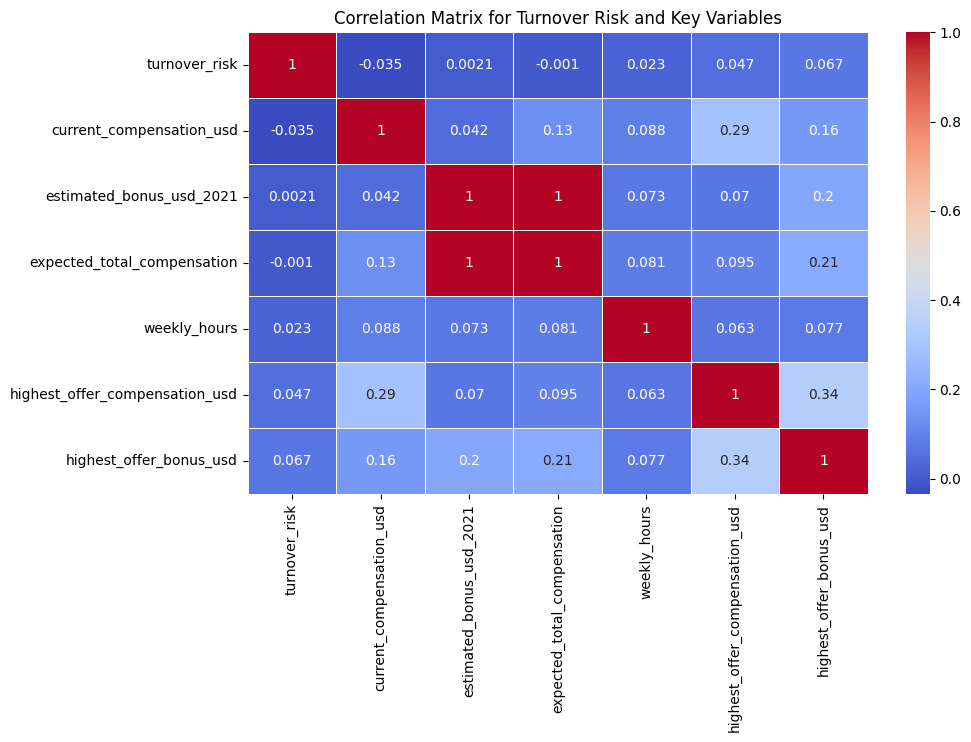

In [ ]:
# Step 2: Recalculate correlations after cleaning the weekly_hours data
turnover_risk_correlation = new_df[['turnover_risk',
                                    'current_compensation_usd',
                                    'estimated_bonus_usd_2021',
                                    'expected_total_compensation',
                                    'weekly_hours',
                                    'highest_offer_compensation_usd',
                                    'highest_offer_bonus_usd']].corr()

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(turnover_risk_correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix for Turnover Risk and Key Variables')
plt.show()


Key Observations:
Turnover Risk:

Highest Offer Bonus (0.068): The highest positive correlation with turnover risk is with the highest bonus offered in external job offers. This suggests that consultants are more likely to leave if they receive significant bonuses elsewhere.
Highest Offer Compensation (0.055): There’s a weak positive correlation between turnover risk and the compensation offered by another firm, indicating that higher salary offers increase turnover slightly.
Weekly Hours (0.023): The number of hours worked per week has a very weak positive correlation with turnover risk, suggesting that hours worked alone do not play a large role in consultants leaving.
Current Compensation:

Negative Correlation (-0.031): There’s a very weak negative correlation between current compensation and turnover risk, meaning those who are paid more are slightly less likely to leave.
Other Correlations:

Highest Offer Compensation and Current Compensation (0.29): A moderate positive correlation between current compensation and the external offers received, implying that those who earn more tend to receive better offers from other firms.
Highest Offer Bonus and Compensation (0.34): There's also a moderate correlation between the bonus received in external offers and the overall compensation in those offers.

In [ ]:
# Select the relevant features for the model
features = new_df[['current_compensation_usd',
                   'estimated_bonus_usd_2021',
                   'expected_total_compensation',
                   'weekly_hours',
                   'highest_offer_compensation_usd',
                   'highest_offer_bonus_usd']]

target = new_df['turnover_risk']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Standardize the feature data (important for models like logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Initialize and train the logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Evaluate the model's performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9345238095238095
Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       786
           1       0.33      0.02      0.04        54

    accuracy                           0.93       840
   macro avg       0.64      0.51      0.50       840
weighted avg       0.90      0.93      0.91       840



Key Metrics:
Accuracy (94%):
The model has a high overall accuracy, which means that 94% of predictions (across both classes) are correct.
Class Imbalance:
The model is performing well for predicting class 0 (those who do not leave), with high precision (94%), recall (100%), and F1-score (97%).
However, for class 1 (those who do leave), the model has 0% precision, recall, and F1-score. This means it is failing to correctly identify any individuals who leave, predicting all of them as non-leavers.


In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

# Train the model again on the resampled data
model.fit(X_resampled, y_resampled)

# Predict on the test data
y_pred_resampled = model.predict(X_test_scaled)

# Evaluate the model again
print("Accuracy after SMOTE:", accuracy_score(y_test, y_pred_resampled))
print("Classification Report after SMOTE:\n", classification_report(y_test, y_pred_resampled))


Accuracy after SMOTE: 0.6083333333333333
Classification Report after SMOTE:
               precision    recall  f1-score   support

           0       0.97      0.60      0.74       786
           1       0.11      0.76      0.20        54

    accuracy                           0.61       840
   macro avg       0.54      0.68      0.47       840
weighted avg       0.92      0.61      0.71       840



In [ ]:
# Train the logistic regression with class weighting
model = LogisticRegression(random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_weighted = model.predict(X_test_scaled)
print("Accuracy with Class Weighting:", accuracy_score(y_test, y_pred_weighted))
print("Classification Report with Class Weighting:\n", classification_report(y_test, y_pred_weighted))


Accuracy with Class Weighting: 0.6011904761904762
Classification Report with Class Weighting:
               precision    recall  f1-score   support

           0       0.97      0.59      0.74       786
           1       0.11      0.74      0.19        54

    accuracy                           0.60       840
   macro avg       0.54      0.67      0.46       840
weighted avg       0.92      0.60      0.70       840



Better Recall for Leavers: The model is now correctly identifying a higher proportion of people who actually leave (recall of 60% for class 1). This is a significant improvement compared to the original result, where recall was 0%.
Trade-off with Accuracy: The accuracy has dropped, and the model now makes more false-positive predictions for class 1 (predicting someone will leave when they won't).
Precision and F1-Score Need Improvement: The precision for predicting leavers is still very low, which means that the model struggles to correctly classify leavers without making many mistakes due to the number of value that is quite low.

In [ ]:
# Prepare features and target
# Convert weekly_hours to numeric categories (e.g., "40-49" -> 1, "50-59" -> 2, etc.)
df['weekly_hours'] = df['weekly_hours'].astype('category').cat.codes

# Encode target variable 'offer_received' (Yes=1, No=0)
label_encoder = LabelEncoder()
df['offer_received'] = label_encoder.fit_transform(df['offer_received'])

# Define feature columns and target column
feature_columns = ['current_compensation_usd', 'estimated_bonus_usd_2021',
                   'expected_total_compensation', 'weekly_hours']
X = df[feature_columns]  # Features
y = df['offer_received']  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest model with class weighting
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.85      0.79       618
           1       0.30      0.18      0.23       222

    accuracy                           0.67       840
   macro avg       0.52      0.52      0.51       840
weighted avg       0.63      0.67      0.64       840

Confusion Matrix:
 [[526  92]
 [182  40]]


In [ ]:
# Select relevant columns for analysis and prediction
relevant_columns = [
    'offer_received', 'offer_from_consulting_firm', 'highest_offer_firm',
    'offer_practice', 'offered_title', 'offer_country',
    'highest_offer_compensation_usd', 'highest_offer_bonus_usd', 'accepted_offer'
]
df = df[relevant_columns]

# Encoding categorical columns
categorical_columns = ['offer_received', 'offer_from_consulting_firm', 'highest_offer_firm',
                       'offer_practice', 'offered_title', 'offer_country', 'accepted_offer']
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Handle missing values
imputer = SimpleImputer(strategy='mean')
df[['highest_offer_compensation_usd', 'highest_offer_bonus_usd']] = imputer.fit_transform(
    df[['highest_offer_compensation_usd', 'highest_offer_bonus_usd']]
)

# Define features and target
X = df.drop('accepted_offer', axis=1)
y = df['accepted_offer']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest model
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance
feature_importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:\n", feature_importance_df)

<ipython-input-24-466ad7a08b1e>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col].astype(str))
<ipython-input-24-466ad7a08b1e>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col].astype(str))
<ipython-input-24-466ad7a08b1e>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.79      0.69       126
           1       0.21      0.16      0.18        44
           2       0.42      0.19      0.26        52
           3       1.00      1.00      1.00       618

    accuracy                           0.88       840
   macro avg       0.56      0.54      0.53       840
weighted avg       0.86      0.88      0.86       840

Confusion Matrix:
 [[100  17   9   0]
 [ 32   7   5   0]
 [ 32  10  10   0]
 [  0   0   0 618]]
Feature Importances:
                           Feature  Importance
6  highest_offer_compensation_usd    0.247419
7         highest_offer_bonus_usd    0.217005
5                   offer_country    0.201193
1      offer_from_consulting_firm    0.109681
0                  offer_received    0.088000
2              highest_offer_firm    0.067690
4                   offered_title    0.046732
3                  offer_practice    0.022282
